# Predição de Rotatividade de Clientes — Model Fitness

## Introdução

A rede de academias **Model Fitness** enfrenta um problema recorrente no setor de fitness: a **rotatividade (churn)** de clientes. Reter um cliente é significativamente mais barato do que conquistar um novo, por isso a academia quer antecipar quais clientes estão propensos a deixar de frequentá-la para agir preventivamente (descontos, convites personalizados, mudanças de serviço).

**Objetivos deste projeto:**
1. Realizar uma análise exploratória dos dados de clientes.
2. Construir um modelo de classificação binária capaz de prever a probabilidade de um cliente dar churn no mês seguinte.
3. Segmentar os clientes em grupos (clusters) com perfis de comportamento semelhantes.
4. Identificar os fatores que mais influenciam a rotatividade e propor recomendações de retenção.

**Dataset:** `gym_churn_us.csv` — características demográficas, contratuais e comportamentais de clientes da academia, com a variável-alvo `Churn` (1 = saiu, 0 = permaneceu).

In [1]:
#importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage  # clustering hierárquico (dendrograma)

from sklearn.model_selection import train_test_split  # split treino/validação
from sklearn.preprocessing import StandardScaler  # padronização (regressão log. e clustering)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

# Semente única reutilizada em todo o notebook (split, modelos, kmeans) para reprodutibilidade
RANDOM_STATE = 42

# Paleta de referência (categórica, ordem fixa) usada em todo o notebook
BLUE = "#2a78d6"    # grupo "ficou" / série 1
RED = "#e34948"     # grupo "saiu" / série 6
CLUSTER_PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"]
GRID_COLOR = "#e1e0d9"

# Configurações visuais (não afetam a análise, só padronizam a aparência dos gráficos)
sns.set_style("whitegrid", {"grid.color": GRID_COLOR, "axes.edgecolor": "#c3c2b7"})
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

pd.set_option("display.max_columns", None)  # mostra todas as colunas nas tabelas
pd.set_option("display.float_format", lambda x: f"{x:0.3f}")  # 3 casas decimais nas tabelas

## 1. Análise Exploratória de Dados (AED)

In [ ]:
df = pd.read_csv("gym_churn_us.csv")
df.columns = [c.strip() for c in df.columns]  # remove espaços acidentais nos nomes de coluna
print(df.shape)
df.head()

In [3]:
# Checa tipos de dado e contagem de não-nulos por coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

### 1.1 Valores ausentes

In [4]:
# Soma de nulos por coluna, mantendo só as que têm algum ausente
missing = df.isna().sum()
missing = missing[missing > 0]
if missing.empty:
    print("Não há valores ausentes em nenhuma coluna do dataset.")
else:
    print(missing)

Não há valores ausentes em nenhuma coluna do dataset.


### 1.2 Estatísticas descritivas

Média e desvio padrão (entre outras estatísticas) de todas as características do dataset.

In [5]:
# Estatísticas descritivas (média, desvio padrão, quartis etc.) de todas as colunas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.000,0.510,0.500,0.000,0.000,1.000,1.000,1.000
Near_Location,4000.000,0.845,0.362,0.000,1.000,1.000,1.000,1.000
Partner,4000.000,0.487,0.500,0.000,0.000,0.000,1.000,1.000
Promo_friends,4000.000,0.308,0.462,0.000,0.000,0.000,1.000,1.000
Phone,4000.000,0.903,0.295,0.000,1.000,1.000,1.000,1.000
Contract_period,4000.000,4.681,4.550,1.000,1.000,1.000,6.000,12.000
Group_visits,4000.000,0.412,0.492,0.000,0.000,0.000,1.000,1.000
Age,4000.000,29.184,3.258,18.000,27.000,29.000,31.000,41.000
Avg_additional_charges_total,4000.000,146.944,96.356,0.148,68.869,136.220,210.950,552.591
Month_to_end_contract,4000.000,4.323,4.191,1.000,1.000,1.000,6.000,12.000


### 1.3 Comparação entre clientes que saíram e que ficaram

Médias de cada característica, agrupadas por `Churn` (0 = ficou, 1 = saiu).

In [6]:
# Média de cada característica por grupo de Churn (0=ficou, 1=saiu) + diferença percentual
churn_means = df.groupby("Churn").mean().T
churn_means.columns = ["Ficou (0)", "Saiu (1)"]
churn_means["Diferença (%)"] = (
    (churn_means["Saiu (1)"] - churn_means["Ficou (0)"]) / churn_means["Ficou (0)"] * 100
)
churn_means

,Ficou (0),Saiu (1),Diferença (%)
gender,0.510,0.511,0.157
Near_Location,0.873,0.768,-12.020
Partner,0.534,0.355,-33.484
Promo_friends,0.354,0.184,-48.012
Phone,0.904,0.903,-0.087
Contract_period,5.747,1.729,-69.923
Group_visits,0.464,0.269,-42.122
Age,29.977,26.990,-9.964
Avg_additional_charges_total,158.446,115.083,-27.368
Month_to_end_contract,5.283,1.663,-68.530


### 1.4 Distribuição das características por grupo

Histogramas comparando a distribuição de cada variável numérica entre clientes que saíram e que ficaram.

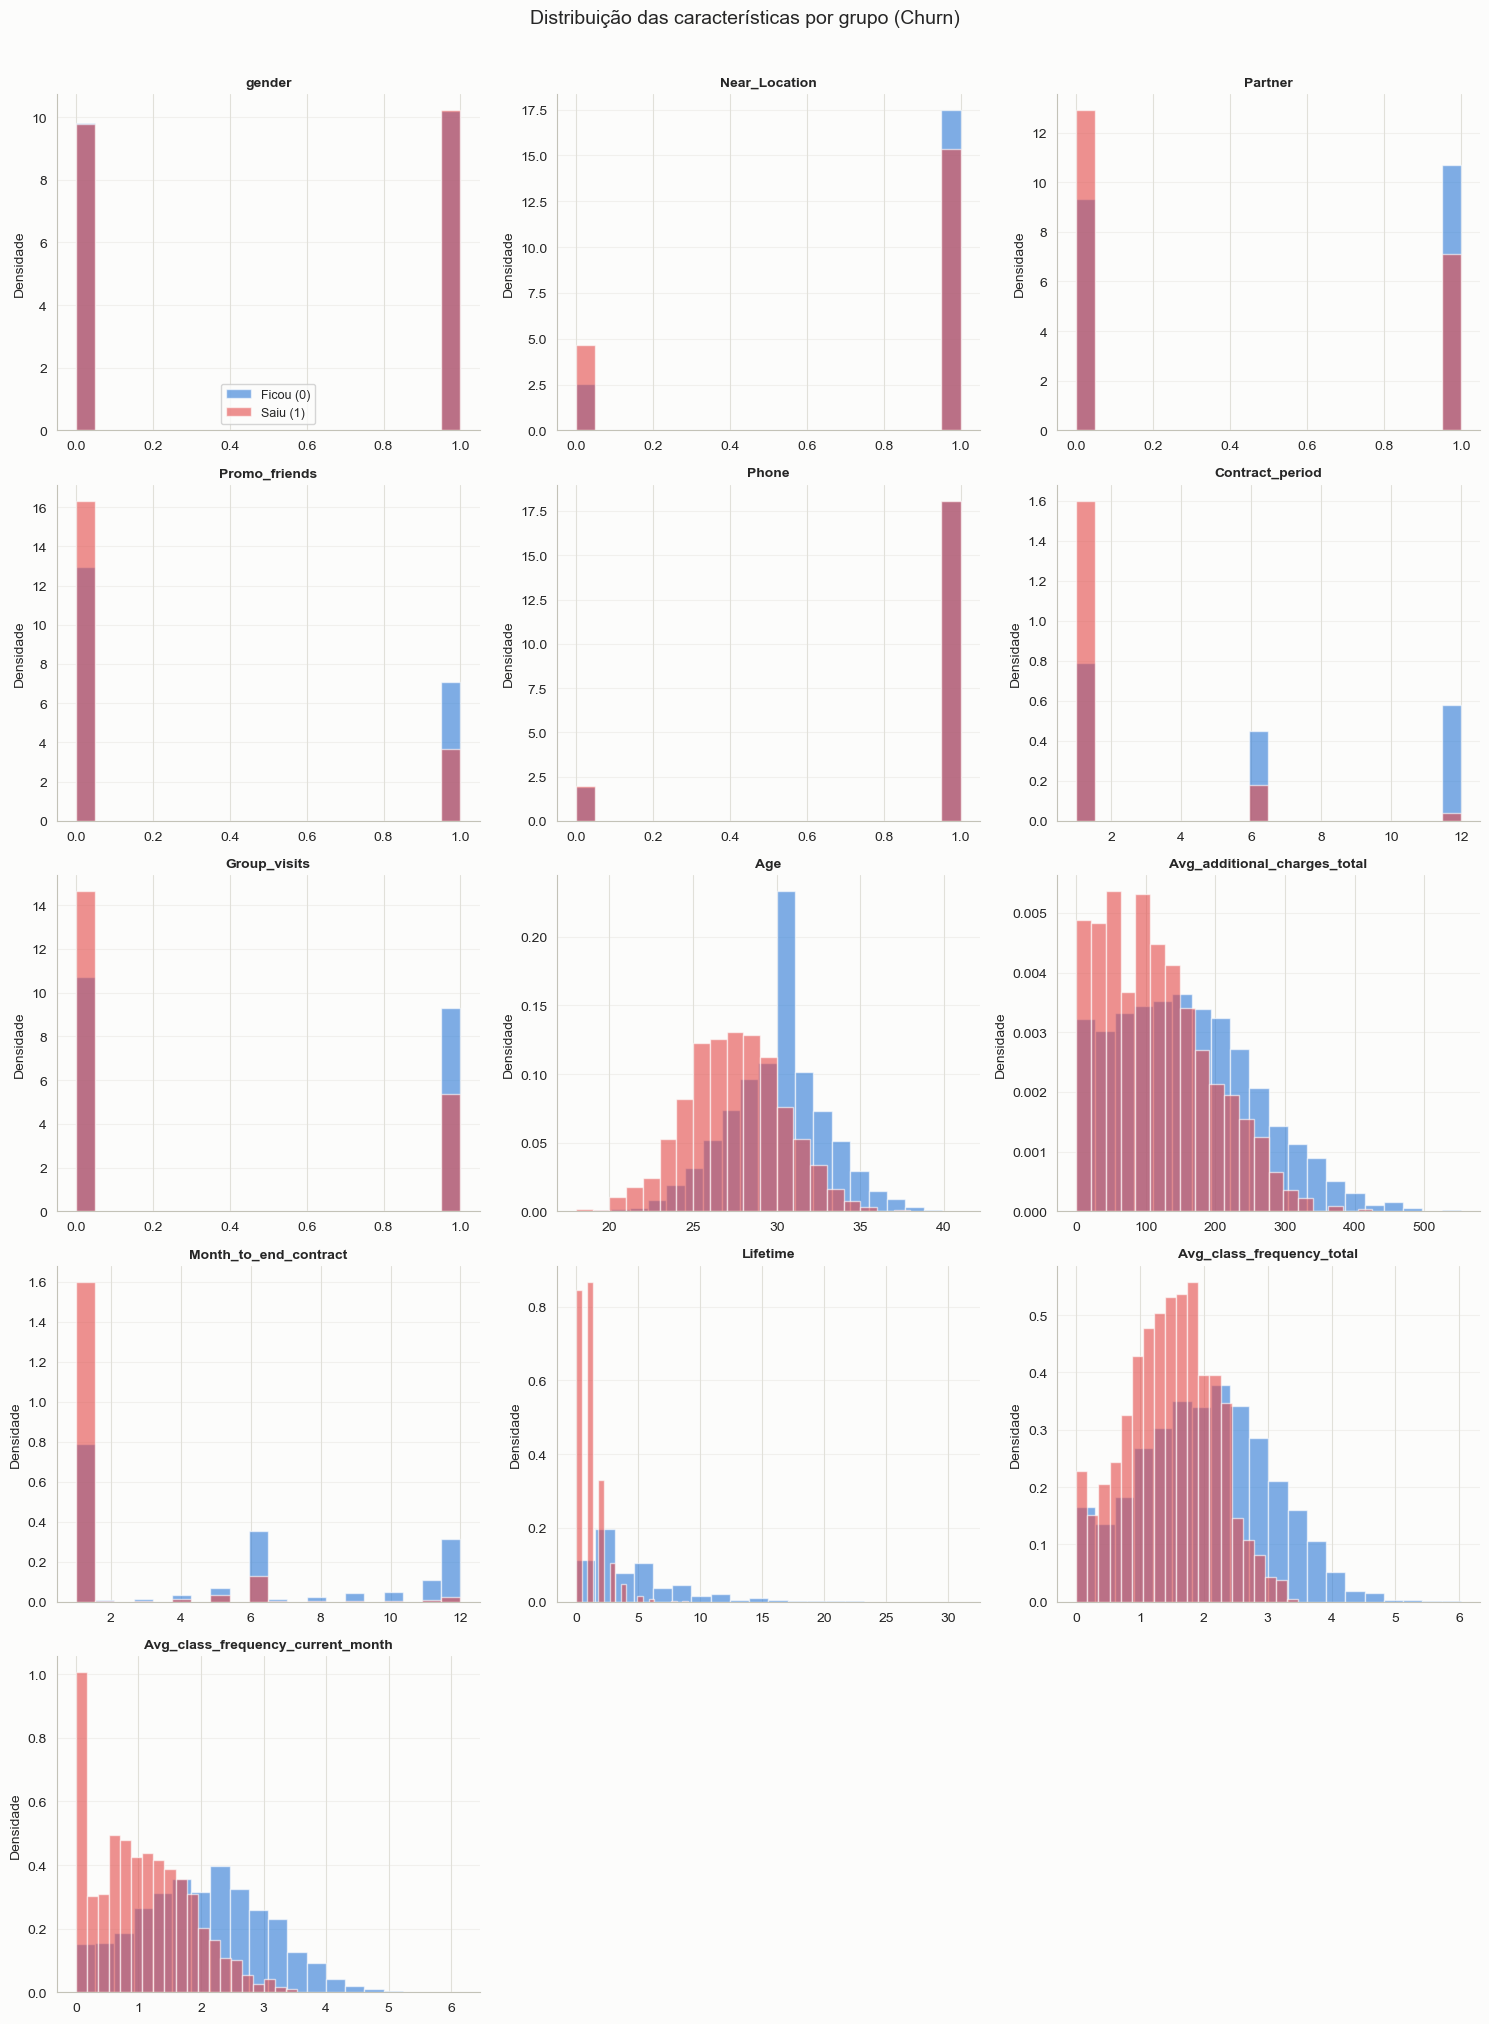

In [7]:
# Um histograma por característica, sobrepondo os dois grupos de Churn (density=True normaliza p/ comparar)
features = [c for c in df.columns if c != "Churn"]
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    ax.hist(df.loc[df["Churn"] == 0, feature], bins=20, alpha=0.6, color=BLUE, label="Ficou (0)", density=True)
    ax.hist(df.loc[df["Churn"] == 1, feature], bins=20, alpha=0.6, color=RED, label="Saiu (1)", density=True)
    ax.set_title(feature, fontsize=10)
    ax.set_ylabel("Densidade")
    ax.grid(axis="y", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    if i == 0:
        ax.legend(fontsize=9)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])  # remove eixos vazios (grade 3xN nem sempre preenche tudo)

fig.suptitle("Distribuição das características por grupo (Churn)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Como ler:** cada painel é uma característica; azul = clientes que ficaram, vermelho = que saíram. Quanto mais separadas/deslocadas as duas curvas, mais essa variável diferencia os dois grupos (ex.: `Lifetime` e `Contract_period` mostram forte separação).

### 1.5 Matriz de correlação

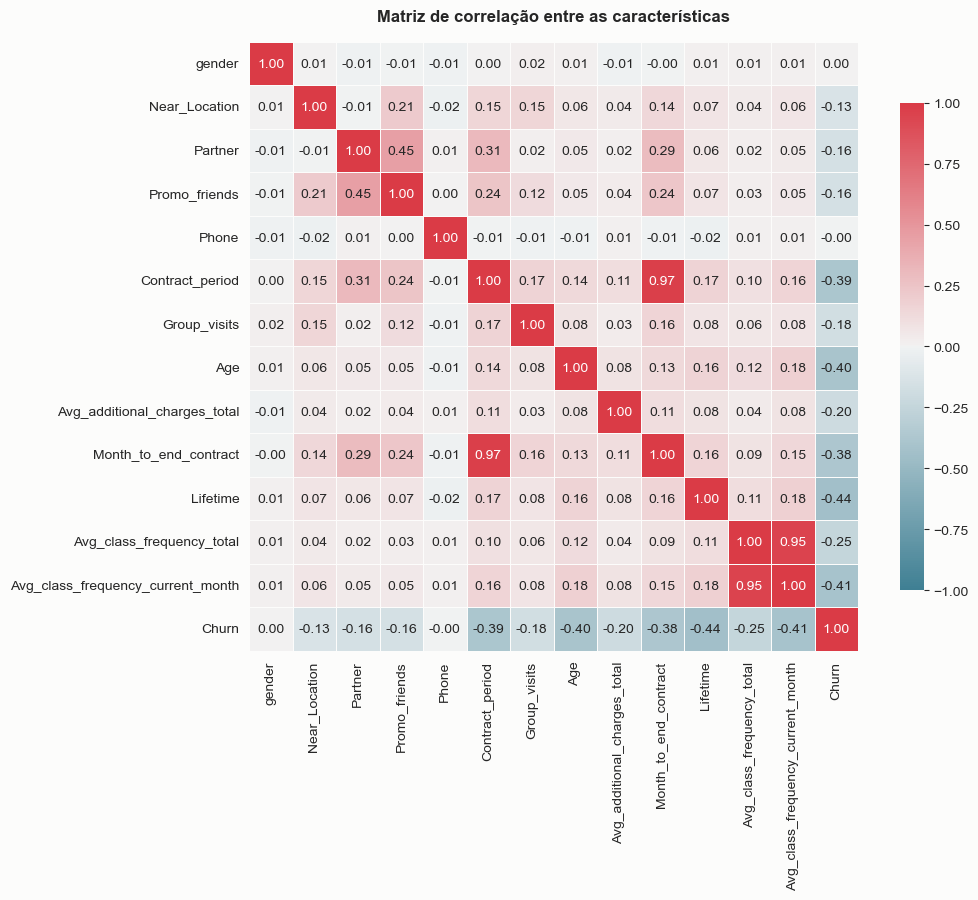

In [8]:
# Correlação de Pearson entre todas as características (inclui Churn) via heatmap
corr = df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(220, 10, s=75, l=50, as_cmap=True)  # eixo azul-vermelho
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="#fcfcfb",
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Matriz de correlação entre as características", pad=15)
plt.tight_layout()
plt.show()

**Como ler:** valores entre -1 e 1; próximo de 1 = correlação positiva forte, de -1 = negativa forte, de 0 = sem relação linear. Olhe a linha/coluna `Churn` para ver quais variáveis mais se associam à saída do cliente.

**Observações da AED:** as variáveis `Lifetime`, `Avg_class_frequency_current_month`, `Avg_class_frequency_total` e `Month_to_end_contract`/`Contract_period` apresentam as maiores diferenças de média entre os grupos de churn e também aparecem fortemente correlacionadas entre si (por exemplo, `Month_to_end_contract` e `Contract_period`), o que é esperado, já que ambas descrevem o mesmo tipo de compromisso contratual.

## 2. Modelo de Classificação Binária (Predição de Churn)

In [9]:
# Separa X (features) e y (alvo), depois divide 80/20 treino/validação
# stratify=y mantém a proporção de churn igual nos dois conjuntos (dataset é desbalanceado: ~26% churn)
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Padronização: necessária para a regressão logística (sensível à escala das variáveis)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit só no treino, evita vazamento de dados
X_valid_scaled = scaler.transform(X_valid)      # validação só recebe transform (mesma escala do treino)

print("Treino:", X_train.shape, " | Validação:", X_valid.shape)

Treino: (3200, 13)  | Validação: (800, 13)


### 2.1 Regressão Logística

In [10]:
# Regressão logística: usa dados padronizados (X_*_scaled)
log_reg = LogisticRegression(random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
pred_log_reg = log_reg.predict(X_valid_scaled)

### 2.2 Floresta Aleatória (Random Forest)

In [11]:
# Random Forest: usa dados NÃO padronizados (árvores são invariantes à escala)
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_valid)

### 2.3 Comparação dos modelos

In [12]:
# Função auxiliar para não repetir o cálculo das 3 métricas pra cada modelo
def get_metrics(y_true, y_pred, model_name):
    return {
        "Modelo": model_name,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Sensibilidade (Recall)": recall_score(y_true, y_pred),
    }

results = pd.DataFrame([
    get_metrics(y_valid, pred_log_reg, "Regressão Logística"),
    get_metrics(y_valid, pred_rf, "Random Forest"),
]).set_index("Modelo")

results

,Acurácia,Precisão,Sensibilidade (Recall)
Modelo,,,
Regressão Logística,0.925,0.880,0.830
Random Forest,0.927,0.885,0.835


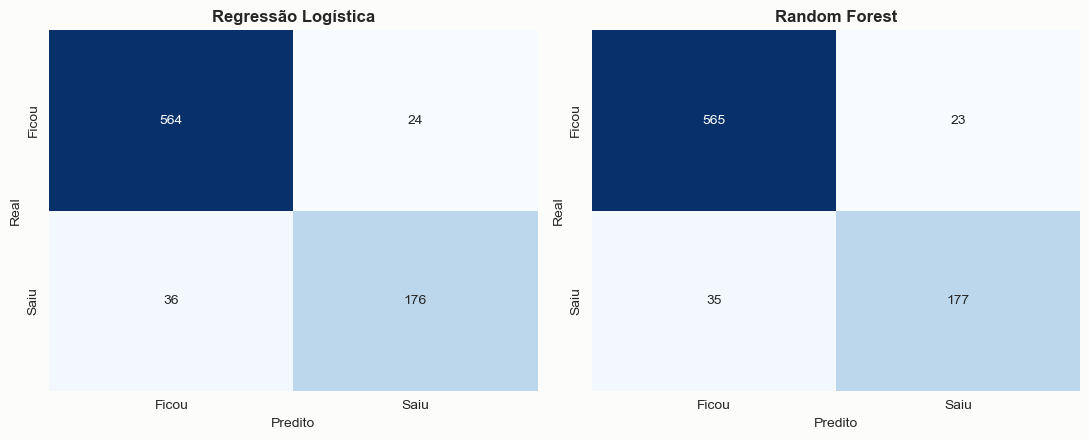

In [13]:
# Matriz de confusão lado a lado, pra ver visualmente onde cada modelo erra (falso positivo/negativo)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, pred) in zip(axes, [("Regressão Logística", pred_log_reg), ("Random Forest", pred_rf)]):
    cm = confusion_matrix(y_valid, pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Ficou", "Saiu"], yticklabels=["Ficou", "Saiu"], ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

**Como ler:** linhas = valor real, colunas = valor previsto. Diagonal principal = acertos; fora dela = erros (falso positivo/negativo). Quanto mais concentrado na diagonal, melhor o modelo.

**Resultado:** o Random Forest teve desempenho ligeiramente superior à Regressão Logística em todas as três métricas (acurácia 0.927 vs 0.925; precisão 0.885 vs 0.880; recall 0.835 vs 0.830). A diferença é pequena — ambos os modelos já capturam bem o padrão de churn, o que indica que as variáveis do dataset (sobretudo `Lifetime`, `Contract_period` e frequência de aulas) são fortemente preditivas. Para uso em produção, o Random Forest é a escolha recomendada por ter recall levemente maior (identifica mais clientes que de fato vão sair, o que é o erro mais custoso de se cometer neste problema de negócio).

## 3. Agrupamento de Clientes (Clustering)

### 3.1 Padronização dos dados

In [14]:
# Exclui Churn (não é feature de agrupamento) e padroniza — K-means usa distância euclidiana,
# então variáveis em escalas diferentes (ex.: Age vs Avg_additional_charges_total) distorceriam os clusters
X_cluster = df.drop(columns=["Churn"])
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

### 3.2 Dendrograma (agrupamento hierárquico)

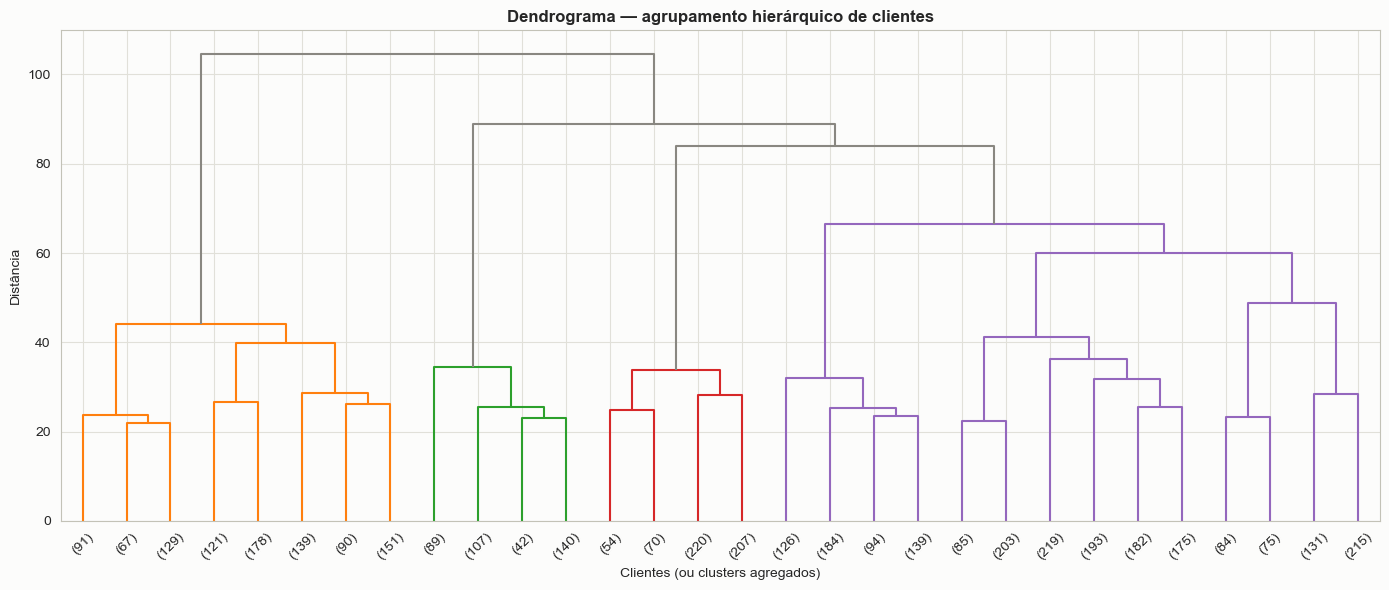

In [15]:
# linkage(method="ward") calcula a matriz de distâncias minimizando variância intra-cluster a cada junção
# truncate_mode="lastp" mostra só os últimos 30 clusters formados (dendrograma completo c/ 4000 folhas seria ilegível)
linked = linkage(X_cluster_scaled, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linked, truncate_mode="lastp", p=30, ax=ax, color_threshold=0.7 * max(linked[:, 2]),
           above_threshold_color="#898781")
ax.set_title("Dendrograma — agrupamento hierárquico de clientes")
ax.set_xlabel("Clientes (ou clusters agregados)")
ax.set_ylabel("Distância")
plt.tight_layout()
plt.show()

**Como ler:** cada linha vertical marca a junção de dois clusters; a altura (eixo Y) é a distância entre eles. Cortando o dendrograma numa altura, o nº de linhas cruzadas = nº de clusters. Saltos grandes de altura indicam o ponto natural de corte.

O dendrograma mostra saltos de distância relevantes na faixa de **4 a 5 agrupamentos**, o que é consistente com a solicitação de negócio de trabalhar com **5 clusters** via K-means, aplicado a seguir.

### 3.3 K-means (n = 5)

In [16]:
# n_clusters=5 pedido pelo negócio (e coerente com o dendrograma). n_init=10 roda o algoritmo
# 10x com centróides iniciais diferentes e mantém o melhor resultado (evita mínimo local ruim)
km = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = km.fit_predict(X_cluster_scaled)
df["cluster"].value_counts().sort_index()

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\DELL\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "c:\Users\DELL\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "c:\Users\DELL\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DELL\anaconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "<frozen codecs>", line 325, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc6 in position 69: invalid continuation byte


cluster
0     544
1     936
2     646
3    1107
4     767
Name: count, dtype: int64

### 3.4 Valores médios das características por agrupamento

In [17]:
# Perfil médio de cada cluster (inclui Churn aqui só para leitura, não foi usado para formar os clusters)
cluster_means = df.groupby("cluster").mean().T
cluster_means

cluster,0,1,2,3,4
gender,0.496,0.499,0.486,0.489,0.585
Near_Location,0.000,0.944,0.998,1.000,0.971
Partner,0.467,0.740,0.824,0.243,0.259
Promo_friends,0.077,0.485,1.000,0.021,0.090
Phone,0.915,0.901,0.899,0.902,0.904
Contract_period,2.210,11.885,3.166,1.986,2.810
Group_visits,0.215,0.551,0.457,0.321,0.477
Age,28.483,29.932,29.224,28.210,30.142
Avg_additional_charges_total,133.630,164.626,141.869,131.152,161.875
Month_to_end_contract,2.074,10.877,2.927,1.902,2.588


### 3.5 Distribuição das características por agrupamento

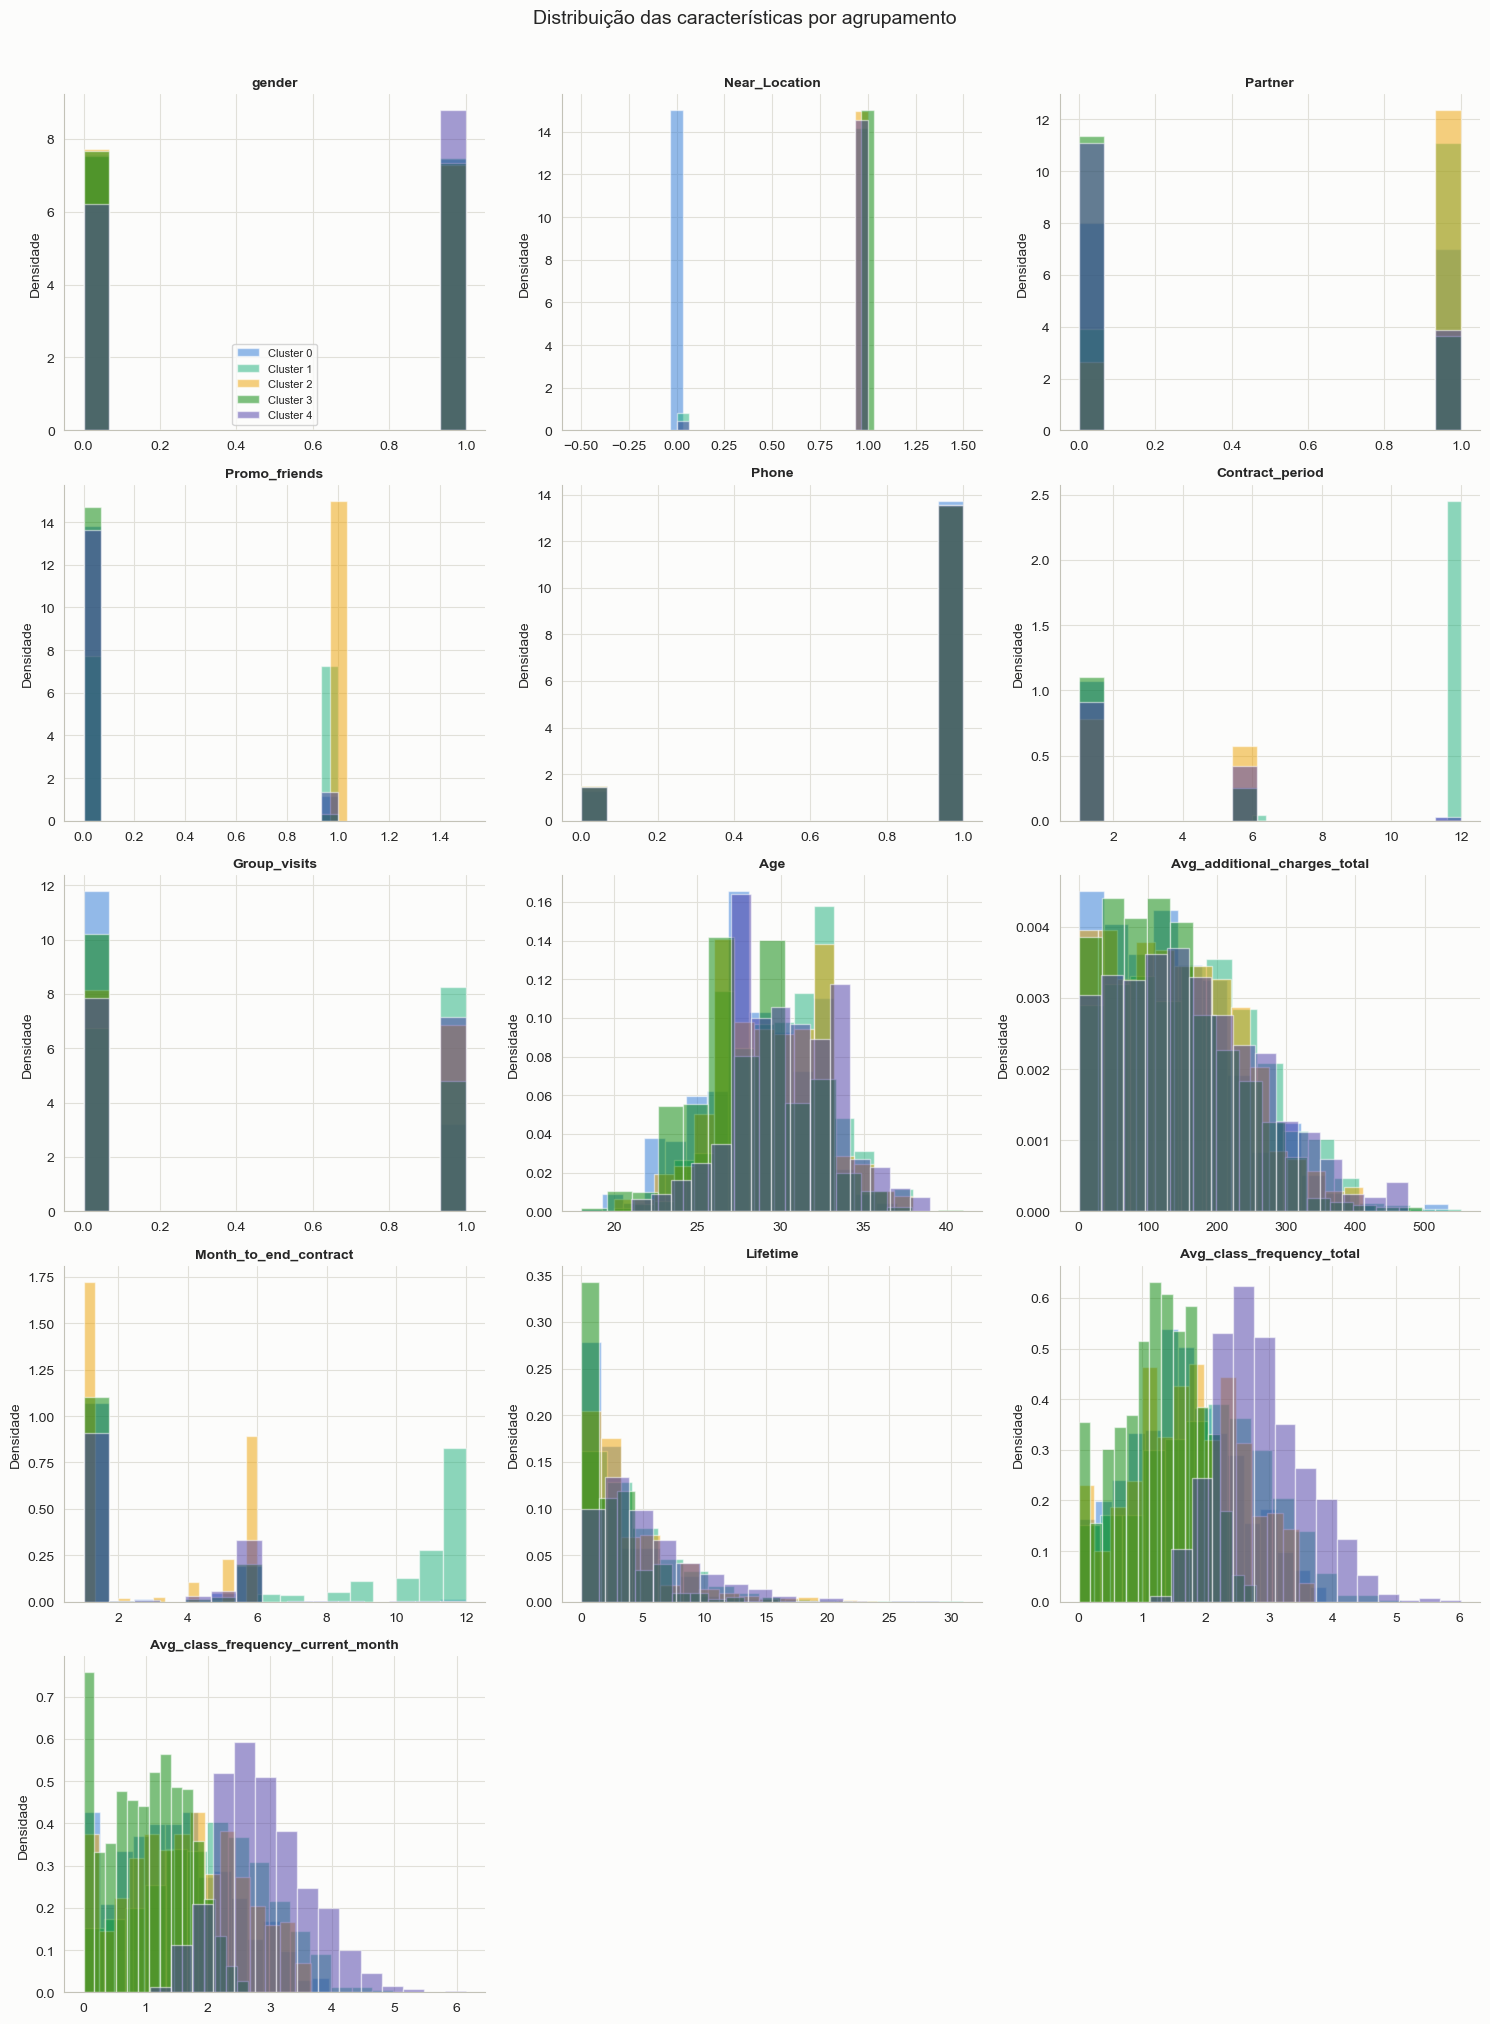

In [18]:
# Mesma lógica dos histogramas por Churn, agora sobrepondo as 5 cores de cluster por característica
features_no_churn = [c for c in df.columns if c not in ("Churn", "cluster")]
n_cols = 3
n_rows = int(np.ceil(len(features_no_churn) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features_no_churn):
    ax = axes[i]
    for c in sorted(df["cluster"].unique()):
        ax.hist(
            df.loc[df["cluster"] == c, feature],
            bins=15, alpha=0.5, density=True,
            color=CLUSTER_PALETTE[c], label=f"Cluster {c}",
        )
    ax.set_title(feature, fontsize=10)
    ax.set_ylabel("Densidade")
    ax.spines[["top", "right"]].set_visible(False)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(len(features_no_churn), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Distribuição das características por agrupamento", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Como ler:** cada painel é uma característica, com uma cor por cluster (0 a 4). Curvas bem separadas nesse painel indicam que a variável foi importante para diferenciar aquele cluster dos demais.

### 3.6 Taxa de churn por agrupamento

In [19]:
# Taxa de churn (% que saiu) e tamanho de cada cluster, ordenado do mais pro menos propenso a sair
cluster_churn = df.groupby("cluster")["Churn"].agg(["mean", "count"]).rename(
    columns={"mean": "Taxa de churn", "count": "Nº de clientes"}
).sort_values("Taxa de churn", ascending=False)
cluster_churn["Taxa de churn"] = cluster_churn["Taxa de churn"] * 100
cluster_churn

,Taxa de churn,Nº de clientes
cluster,,
3,52.665,1107
0,45.037,544
2,24.613,646
4,6.910,767
1,2.244,936


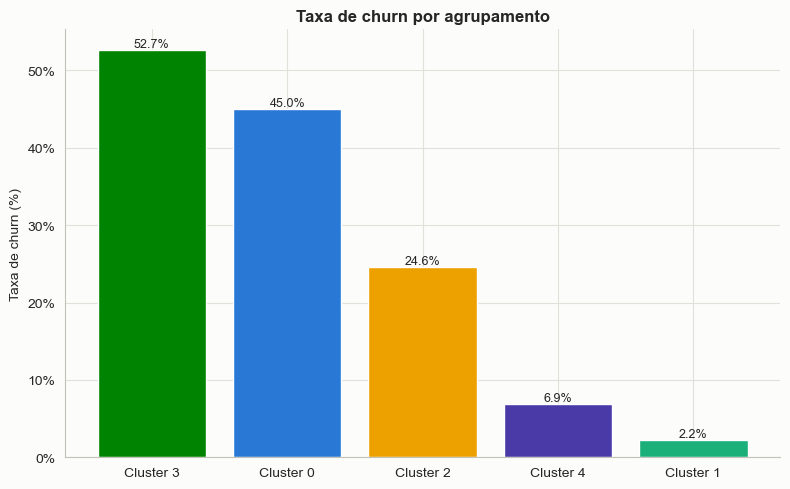

In [20]:
# Gráfico de barras da taxa de churn por cluster, com o valor anotado em cima de cada barra
fig, ax = plt.subplots(figsize=(8, 5))
order = cluster_churn.index
bars = ax.bar(
    [f"Cluster {c}" for c in order],
    cluster_churn["Taxa de churn"],
    color=[CLUSTER_PALETTE[c] for c in order],
)
ax.set_ylabel("Taxa de churn (%)")
ax.set_title("Taxa de churn por agrupamento")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.spines[["top", "right"]].set_visible(False)
for bar, value in zip(bars, cluster_churn["Taxa de churn"]):
    ax.annotate(f"{value:.1f}%", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

**Como ler:** barras ordenadas da maior para a menor taxa de churn; o número no topo é o % de clientes daquele cluster que saíram. Barras à esquerda = maior risco de saída; à direita = clusters mais fiéis.

## 4. Conclusões e Recomendações

### Principais achados

1. **Contrato longo é o fator de retenção mais forte.** O Cluster 1 (936 clientes, contrato médio de ~12 meses) tem a menor taxa de churn de todos: **2.2%**. Já o Cluster 3 (1.107 clientes, contrato médio de ~2 meses) é o mais propenso a sair, com **52.7%** de churn. Isso é confirmado na AED geral: `Contract_period` cai 70% (de 5.75 para 1.73 meses) entre quem fica e quem sai — a variável com maior diferença relativa entre os dois grupos.

2. **Frequência de uso em queda é um sinal de alerta precoce.** No Cluster 3 (maior churn), a frequência de aulas no mês atual (1.03) já é menor que a frequência histórica (1.27), indicando desengajamento antes da saída. No Cluster 4, o mais fiel depois do Cluster 1 (churn de 6.9%), ocorre o oposto: a frequência atual (2.88) é igual ou superior à histórica, sinal de engajamento crescente.

3. **Não morar/trabalhar perto da academia é um forte indicador de risco.** O Cluster 0 (544 clientes) tem `Near_Location = 0` para 100% dos seus membros e a segunda maior taxa de churn (**45.0%**), mesmo com contratos de duração parecida à do Cluster 3. Isso é coerente com a AED: `Near_Location` é 12% menor entre quem sai.

4. **Aquisição via indicação de parceiros/amigos está associada a maior fidelidade.** Clientes que chegaram por `Partner` ou `Promo_friends` têm médias de churn na base geral 33% e 48% menores, respectivamente, do que quem não usou esses canais. O Cluster 2, formado quase inteiramente por indicados (`Promo_friends = 1.0`), tem churn moderado (24.6%) mesmo com contratos curtos (~3 meses) — sugerindo que o vínculo social amortece parte do risco de saída.

5. **O modelo preditivo é confiável para uso operacional.** O Random Forest atingiu 92.7% de acurácia, 88.5% de precisão e 83.5% de recall na validação — desempenho suficiente para priorizar ações de retenção em clientes de alto risco antes que eles efetivamente saiam.

### Recomendações práticas

- **Incentivar migração para contratos mais longos.** Oferecer desconto progressivo ou benefício adicional (ex.: aulas em grupo gratuitas) para quem migrar de um contrato mensal para trimestral/semestral/anual — é o alavanca individual mais forte contra o churn.
- **Criar um alerta de "frequência em queda".** Sinalizar automaticamente clientes cuja `Avg_class_frequency_current_month` cair abaixo da própria média histórica (`Avg_class_frequency_total`) — esse padrão aparece exatamente nos clusters de maior churn (0 e 3) — e disparar contato proativo (e-mail, ligação, oferta personalizada) antes da saída.
- **Reforçar conveniência para clientes que não moram/trabalham perto da unidade** (Cluster 0): horários alternativos, aulas online/híbridas, ou parcerias com transporte, já que a distância parece ser o principal fator de risco desse grupo.
- **Expandir programas de indicação (`Promo_friends`) e parcerias corporativas (`Partner`).** Esses canais trazem clientes com churn consistentemente menor — ampliar incentivos de indicação (ex.: mês grátis para quem indica) tende a melhorar tanto aquisição quanto retenção.
- **Usar o modelo de classificação para priorizar contato de retenção.** Rodar o Random Forest mensalmente sobre a base ativa e direcionar campanhas de retenção (desconto, contato do instrutor, oferta de upgrade de plano) para o grupo com maior probabilidade prevista de churn — em particular os perfis semelhantes aos Clusters 0 e 3 (contrato curto, baixa frequência recente, sem indicação/parceria).
- **Tratar Cluster 1 e Cluster 4 como base de referência de fidelidade** — clientes com contrato longo, alta frequência e bom gasto em serviços adicionais. Vale entender o que os atrai (ex.: aulas em grupo, atendimento) e replicar esses elementos para os demais segmentos.